SVM
Goal of SVM

👉 Find the best line that separates two classes with the maximum margin

Margin = distance between the two parallel boundary lines.

Bigger margin → better generalization

SVM chooses the line that maximizes margin

2️⃣ Equation of the line

The decision boundary is written as:

𝑤
𝑇
𝑥
+
𝑏
=
0
w
T
x+b=0

Where:

w → weight vector (direction of the line)

b → bias (shifts the line)

x → input feature

The two margin lines are:

𝑤
𝑇
𝑥
+
𝑏
=
+
1
w
T
x+b=+1
𝑤
𝑇
𝑥
+
𝑏
=
−
1
w
T
x+b=−1
3️⃣ Why minimize 
∥
𝑤
∥
∥w∥?

On the board you see:

Minimize 
∣
∣
𝑤
∣
∣
2
Minimize 
2
∣∣w∣∣
	​

Reason:

Margin = 
2
∣
∣
𝑤
∣
∣
∣∣w∣∣
2
	​


To maximize margin, we minimize 
∣
∣
𝑤
∣
∣
∣∣w∣∣

This is why SVM optimization focuses on minimizing the magnitude of weights.

4️⃣ Cost Function (Very Important)

In the second screenshot you see “Cost function → Min”
This is where hinge loss comes in.

Hinge Loss formula:
𝐶
𝑖
=
max
⁡
(
0
,
  
1
−
𝑦
𝑖
(
𝑤
𝑇
𝑥
𝑖
+
𝑏
)
)
C
i
	​

=max(0,1−y
i
	​

(w
T
x
i
	​

+b))

Where:

𝑦
𝑖
y
i
	​

 = class label (+1 or −1)

𝑥
𝑖
x
i
	​

 = data point

5️⃣ What hinge loss means intuitively
Case 1: Correct & far from boundary
𝑦
(
𝑤
𝑇
𝑥
+
𝑏
)
≥
1
y(w
T
x+b)≥1

✔ No loss

𝐶
𝑖
=
0
C
i
	​

=0
Case 2: Correct but inside margin
0
<
𝑦
(
𝑤
𝑇
𝑥
+
𝑏
)
<
1
0<y(w
T
x+b)<1

⚠ Small penalty
SVM tries to push it outside margin

Case 3: Misclassified point
𝑦
(
𝑤
𝑇
𝑥
+
𝑏
)
<
0
y(w
T
x+b)<0

❌ Large penalty
SVM strongly penalizes this

6️⃣ Final SVM Objective Function (What the teacher boxed)
min
⁡
(
1
2
∣
∣
𝑤
∣
∣
2
+
𝐶
∑
𝐶
𝑖
)
min(
2
1
	​

∣∣w∣∣
2
+C∑C
i
	​

)
Meaning:

First term → maximize margin

Second term → penalize misclassification

C → controls trade-off

C value	Effect
Large C	Less errors, smaller margin
Small C	Larger margin, allows some errors
7️⃣ Support Vectors (Why some points are special)

The points touching the margin lines are called:
👉 Support Vectors

They define the boundary

Other points don’t affect the model

That’s why SVM is efficient and robust.

🔑 Summary in One Line

SVM finds the line that separates classes with the largest margin while penalizing points that violate the margin using hinge loss.

# SVM Kernel


1.Polynomial Kernel
2.RBf
3.Sigmoid
4.Linear

In [13]:
!pip install numpy pandas seaborn matplotlib scikit-learn

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# lets create synthetic data points
from sklearn.datasets import make_classification

x,y= make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)# lets create synthetic data points
from sklearn.datasets import make_classification

x,y= make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

<Axes: xlabel='0', ylabel='1'>

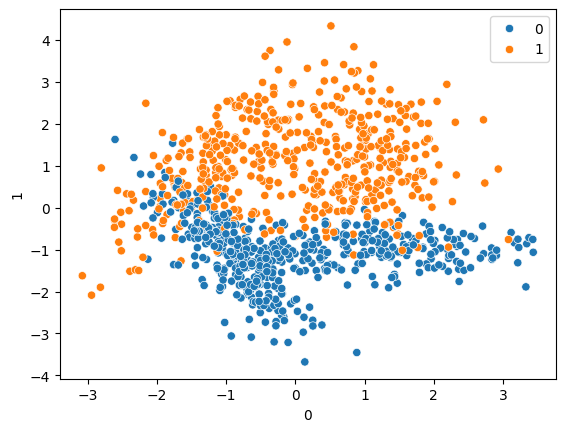

In [14]:
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=10)
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(x_train,y_train)
svc.coef_

y_pred=svc.predict(x_test)

from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       122
           1       0.93      0.88      0.91       128

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

[[114   8]
 [ 15 113]]


In [16]:
rbf=SVC(kernel="rbf")
rbf.fit(x_train,y_train)
y_pred1=rbf.predict(x_test)
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       122
           1       0.93      0.88      0.91       128

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

[[114   8]
 [ 15 113]]


In [17]:
poly=SVC(kernel="poly")
poly.fit(x_train,y_train)
y_pred2=poly.predict(x_test)
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87       122
           1       0.85      0.94      0.89       128

    accuracy                           0.88       250
   macro avg       0.89      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250

[[100  22]
 [  8 120]]


In [18]:
sigmoid=SVC(kernel="sigmoid")
sigmoid.fit(x_train,y_train)
y_pred2=sigmoid.predict(x_test)
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       122
           1       0.89      0.88      0.88       128

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250

[[108  14]
 [ 16 112]]


# Hyper Parameter Tuning with SVC


In [20]:
from sklearn.model_selection import GridSearchCV
param_grid={'C':[0.1,1,10,100,1000],'gamma':[1,0.1,0.01,0.001,0.0001],'kernel':['rbf']}
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,cv=5,verbose=3)
grid.fit(x_train,y_train)
grid.best_params_
y_pred4=grid.predict(x_test)
print(classification_report(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.860 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.900 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

C ---> Regularization Parameter

gamma ---> Influence of a single data point

Total Combination:
5(C)*5(gamma)*1(kernel)=25models

here we used GridSearchCV is used to perform hyperparameter tunning

It checks all combos of given parameters using cv and selects the model with best performance....